# August 2026 desktop — raw model (no adjustments) with prediction intervals

The canonical August desktop config (**g01**) re-run at the published **2026-08-02** seam on the same cached
raw pull, with `l` / `o` off, `h` not applied, Iran fill on. Intervals are Prophet predictive intervals taken as
**quantiles of the 28-day trailing mean across the 1,000 stored sample paths**. Not canonical; changes nothing
published. Full write-up: `_index.md` beside this notebook.

Cells: `[setup]` → `[recompute-intervals]` (optional, ~30 s, re-reads the pickle) → `[dec15-table]` →
`[plot-28ma]` → `[plot-zoom]` → `[method-check]`.


In [1]:
# [setup]
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "src" / "mozaic_daily").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "src"))

BUILD_DIR = REPO_ROOT / "data-official/2026-08/desktop_raw_ci_2026-08-02"
SLUG = "cps0.1649_thresh032_recent17_cpr0.814_ncp40_clip0.6_sps0.00825_regimemultiplicative"
FORECAST_START = "2026-08-02"
PKL_PATH = BUILD_DIR / SLUG / f"mozaic_objects.legacy_desktop.{FORECAST_START}.pkl"
PARQUET_PATH = BUILD_DIR / SLUG / f"mozaic_daily_forecast.{FORECAST_START}.ld-D.raw.parquet"
STEM = "desktop_raw"
ANCHOR_DATE = pd.Timestamp("2026-12-15")
LEVELS = ["50", "80", "90"]

# Published August desktop figures, read from the cycle's own CSVs rather than typed in.
PUBLISHED_SUMMARY = REPO_ROOT / "data-official/2026-08/csv/august_dec15_summary.csv"
PUBLISHED_NO_H_SUMMARY = REPO_ROOT / "data-official/2026-08/csv/august_dec15_summary.DESKTOP_ONLY.WIN10_HEADWIND_REMOVED.csv"
published = pd.read_csv(PUBLISHED_SUMMARY).set_index("series").loc["Desktop", "current_august"]
published_no_h = pd.read_csv(PUBLISHED_NO_H_SUMMARY).set_index("series").loc["Desktop", "current_august_NO_WIN10_HEADWIND"]
REFERENCES = {
    "published Aug (l+o+h applied)": int(published),
    "published Aug, h removed (l+o only)": int(published_no_h),
}
print(f"build dir  {BUILD_DIR}")
print(f"pkl exists {PKL_PATH.exists()}  parquet exists {PARQUET_PATH.exists()}")
print(f"references {REFERENCES}")


build dir  /Users/brendanwells/work/mozaic-daily-august/data-official/2026-08/desktop_raw_ci_2026-08-02
pkl exists True  parquet exists True
references {'published Aug (l+o+h applied)': 48703443, 'published Aug, h removed (l+o only)': 50018443}


In [2]:
# [recompute-intervals]
# Re-derives csv/, plots/ and desktop_raw_summary.json from the pickle. Skipped automatically when the
# pickle is not on disk (it is gitignored; restore it from the GCS archive named in _index.md).
if PKL_PATH.exists():
    cmd = [
        sys.executable, str(REPO_ROOT / "scripts/compute_forecast_intervals.py"),
        "--pkl", str(PKL_PATH), "--forecast-parquet", str(PARQUET_PATH), "--out-dir", str(BUILD_DIR),
    ] + [arg for label, value in REFERENCES.items() for arg in ("--reference", f"{label}={value}")]
    result = subprocess.run(cmd, capture_output=True, text=True)
    print("\n".join(line for line in result.stdout.splitlines() if "Warning" not in line))
    if result.returncode != 0:
        print(result.stderr[-3000:])
        raise RuntimeError(f"compute_forecast_intervals.py exited {result.returncode}")
else:
    print(f"Pickle not on disk ({PKL_PATH.name}); using the committed csv/ and summary outputs as-is.")


Loading pickle /Users/brendanwells/work/mozaic-daily-august/data-official/2026-08/desktop_raw_ci_2026-08-02/cps0.1649_thresh032_recent17_cpr0.814_ncp40_clip0.6_sps0.00825_regimemultiplicative/mozaic_objects.legacy_desktop.2026-08-02.pkl ...
Median path reproduces the parquet world forecast (worst |dev| 0.0000 DAU) — 1000 paths

desktop_raw 28d-MA on 2026-12-15: point forecast 49,935,359 (trailing mean of the median path); band-centre median 49,916,850
  50%: [48,934,166, 51,028,125]  half-width 1,046,979
  80%: [46,705,607, 53,004,274]  half-width 3,149,333
  90%: [45,007,113, 54,629,301]  half-width 4,811,094
  reference published Aug (l+o+h applied): 48,703,443
  reference published Aug, h removed (l+o only): 50,018,443
Trough (28d-MA median) 2026-08-25: 45,305,971

Wrote /Users/brendanwells/work/mozaic-daily-august/data-official/2026-08/desktop_raw_ci_2026-08-02/csv/desktop_raw_*.csv, /Users/brendanwells/work/mozaic-daily-august/data-official/2026-08/desktop_raw_ci_2026-08-02/plots/

In [3]:
# [dec15-table]
summary = json.loads((BUILD_DIR / f"{STEM}_summary.json").read_text())
anchor = summary["anchor_28ma"]

rows = [("raw model point forecast (mean of median path)", anchor["point_forecast_28ma"], None, None),
        ("raw model band centre (median of path means)", anchor["median"], None, None)]
for pct in LEVELS:
    rows.append((f"{pct}% interval", None, anchor[f"lower_{pct}"], anchor[f"upper_{pct}"]))
for label, value in REFERENCES.items():
    rows.append((label, value, None, None))

table = pd.DataFrame(rows, columns=["series", "value", "lower", "upper"])
table["half_width"] = (table["upper"] - table["lower"]) / 2
fmt = lambda v: "" if pd.isna(v) else f"{v:,.0f}"
print(f"Desktop world 28d-MA on {anchor['date']}  (seam {summary['forecast_start_date']}, {summary['n_sample_paths']} paths)\n")
print(table.to_string(index=False, formatters={c: fmt for c in ["value", "lower", "upper", "half_width"]}))

overlay_effect = REFERENCES["published Aug, h removed (l+o only)"] - anchor["point_forecast_28ma"]
print(f"\nl+o combined Dec-15 effect on this config: {overlay_effect:+,.0f}")
print(f"trough of the raw 28d-MA median: {summary['trough_28ma']['median']:,.0f} on {summary['trough_28ma']['trough_date']}")
print(f"median path vs parquet worst |dev|: {summary['median_vs_parquet_worst_abs_dev']:.4f} DAU")


Desktop world 28d-MA on 2026-12-15  (seam 2026-08-02, 1000 paths)

                                        series      value      lower      upper half_width
raw model point forecast (mean of median path) 49,935,359        NaN        NaN        NaN
  raw model band centre (median of path means) 49,916,850        NaN        NaN        NaN
                                  50% interval        NaN 48,934,166 51,028,125  1,046,979
                                  80% interval        NaN 46,705,607 53,004,274  3,149,333
                                  90% interval        NaN 45,007,113 54,629,301  4,811,094
                 published Aug (l+o+h applied) 48,703,443        NaN        NaN        NaN
           published Aug, h removed (l+o only) 50,018,443        NaN        NaN        NaN

l+o combined Dec-15 effect on this config: +83,084
trough of the raw 28d-MA median: 45,305,971 on 2026-08-25
median path vs parquet worst |dev|: 0.0000 DAU


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


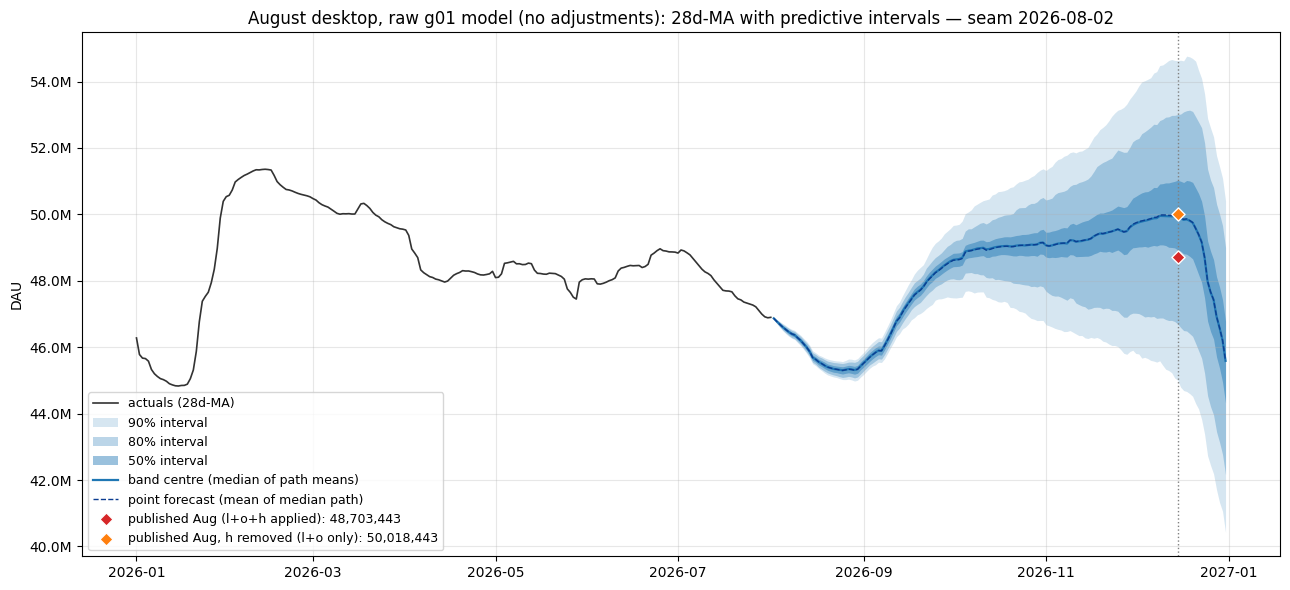

saved /Users/brendanwells/work/mozaic-daily-august/data-official/2026-08/desktop_raw_ci_2026-08-02/plots/desktop_raw_28ma_bands.notebook.png


In [4]:
# [plot-28ma]
from mozaic_daily import intervals  # noqa: E402  (path set in [setup])

ma = pd.read_csv(BUILD_DIR / "csv" / f"{STEM}_28ma_bands.csv", parse_dates=["date"]).set_index("date")
daily = pd.read_csv(BUILD_DIR / "csv" / f"{STEM}_daily_bands.csv", parse_dates=["date"]).set_index("date")
ALPHAS = {"50": 0.45, "80": 0.30, "90": 0.18}
REF_COLORS = ("#d62728", "#ff7f0e")


def draw_bands(ax, frame, show_point_forecast=True):
    for pct in sorted(LEVELS, key=int, reverse=True):
        ax.fill_between(frame.index, frame[f"lower_{pct}"], frame[f"upper_{pct}"],
                        color="#1f77b4", alpha=ALPHAS[pct], linewidth=0, label=f"{pct}% interval")
    ax.plot(frame.index, frame["median"], color="#1f77b4", linewidth=1.6, label="band centre (median of path means)")
    if show_point_forecast and "point_forecast_28ma" in frame:
        ax.plot(frame.index, frame["point_forecast_28ma"], color="#0b3d91", linewidth=1.0, linestyle="--",
                label="point forecast (mean of median path)")
    ax.axvline(ANCHOR_DATE, color="grey", linestyle=":", linewidth=1)
    for (label, value), color in zip(REFERENCES.items(), REF_COLORS):
        ax.scatter([ANCHOR_DATE], [value], marker="D", s=45, color=color, edgecolor="white", zorder=5,
                   label=f"{label}: {value:,.0f}")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v / 1e6:.1f}M"))
    ax.grid(alpha=0.3)


fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(ma.index, ma["actuals_28ma"], color="#333333", linewidth=1.2, label="actuals (28d-MA)")
draw_bands(ax, ma)
ax.set_title(f"August desktop, raw g01 model (no adjustments): 28d-MA with predictive intervals — seam {FORECAST_START}")
ax.set_ylabel("DAU")
ax.legend(loc="lower left", fontsize=9)
fig.tight_layout()
fig.savefig(BUILD_DIR / "plots" / f"{STEM}_28ma_bands.notebook.png", dpi=130)
plt.show()
print(f"saved {BUILD_DIR / 'plots' / (STEM + '_28ma_bands.notebook.png')}")


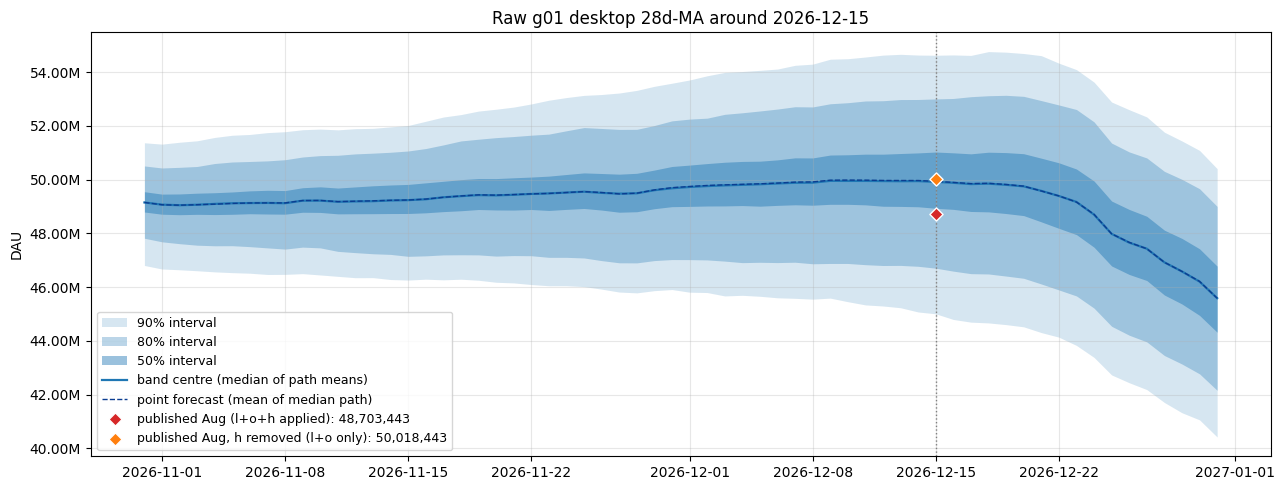

28d-MA band width (upper − lower) by date:
                   50         80         90
date                                       
2026-08-02     27,304     53,630     68,819
2026-09-01    250,196    471,088    660,882
2026-10-01    403,030  1,114,132  2,181,625
2026-11-01    747,929  2,747,944  4,647,154
2026-12-15  2,093,958  6,298,667  9,622,188
2026-12-31  2,459,195  6,843,611  9,986,417


In [5]:
# [plot-zoom]
zoom = ma.loc[ANCHOR_DATE - pd.Timedelta(days=45): ANCHOR_DATE + pd.Timedelta(days=16)]
fig, ax = plt.subplots(figsize=(13, 5))
draw_bands(ax, zoom)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v / 1e6:.2f}M"))
ax.set_title(f"Raw g01 desktop 28d-MA around {ANCHOR_DATE.date()}")
ax.set_ylabel("DAU")
ax.legend(loc="lower left", fontsize=9)
fig.tight_layout()
plt.show()

# Band width over the horizon: how fast the model's own uncertainty grows.
width = pd.DataFrame({pct: ma[f"upper_{pct}"] - ma[f"lower_{pct}"] for pct in LEVELS}).dropna()
checkpoints = [FORECAST_START, "2026-09-01", "2026-10-01", "2026-11-01", "2026-12-15", "2026-12-31"]
print("28d-MA band width (upper − lower) by date:")
print(width.loc[[pd.Timestamp(d) for d in checkpoints]].map(lambda v: f"{v:,.0f}").to_string())


In [6]:
# [method-check]
# Two facts a reader should be able to verify from the CSVs alone, without the pickle.
# 1. The point forecast column is a plain trailing-28 mean of (actuals, then parquet forecast).
from mozaic_daily.adjustments import load_forecast  # noqa: E402

df, meta = load_forecast(str(PARQUET_PATH))
world = df[(df["country"] == "ALL") & (df["segment"] == '{"os": "ALL"}')].copy()
world["target_date"] = pd.to_datetime(world["target_date"])
world = world.set_index("target_date").sort_index()["dau"]
plain_ma = world.rolling(28).mean()
dev = (plain_ma.reindex(ma.index) - ma["point_forecast_28ma"]).abs().dropna()
print(f"point_forecast_28ma == rolling(28) of the parquet world series: worst |dev| {dev.max():.6f} DAU")
assert dev.max() <= 0.005 + 1e-9  # the CSV is written at two decimals
print(f"adjustments in the parquet sidecar: {meta['adjustments_applied'] or 'none (raw)'}")

# 2. The MA band is narrower than the daily band on the same date — the signature of taking
#    quantiles AFTER averaging (day-to-day noise cancels inside the window).
d, m = daily.loc[ANCHOR_DATE], ma.loc[ANCHOR_DATE]
for pct in LEVELS:
    daily_w, ma_w = d[f"upper_{pct}"] - d[f"lower_{pct}"], m[f"upper_{pct}"] - m[f"lower_{pct}"]
    print(f"{pct}% width on {ANCHOR_DATE.date()}: daily {daily_w:,.0f}  28d-MA {ma_w:,.0f}  ratio {ma_w / daily_w:.2f}")
    assert ma_w < daily_w


point_forecast_28ma == rolling(28) of the parquet world series: worst |dev| 0.004975 DAU
adjustments in the parquet sidecar: none (raw)
50% width on 2026-12-15: daily 3,621,282  28d-MA 2,093,958  ratio 0.58
80% width on 2026-12-15: daily 8,847,716  28d-MA 6,298,667  ratio 0.71
90% width on 2026-12-15: daily 13,445,020  28d-MA 9,622,188  ratio 0.72
